# Algorytm dolna i górna otoczka

Załadowanie potrzebnych struktur i testów

In [1]:
%run interface.ipynb
%run tests.ipynb

### Algorytm dolna i górna otoczka - wersja bez wizualizacji algorytmu

In [2]:
def position(a, b, c):
    # okresla polozenie punktu wzgledem zadanej prostej
    result = (b.x - a.x) * (c.y - a.y) - (b.y - a.y) * (c.x - a.x)
    return 1 if result > 0 else -1 if result < 0 else 0

In [3]:
def upper_and_lower_hull(points):
    
    if len(points) <= 2:
        return points
    
    # początkowe sortowanie wszystkich punktów
    sorted_points = sorted(points, key = lambda point: (point.x, point.y))
    
    # przyporządkowanie początkowych punktów do obu elementów otoczki
    upper_hull = [sorted_points[0], sorted_points[1]]
    lower_hull = [sorted_points[0], sorted_points[1]]
    
    for point in sorted_points:
        
        while len(upper_hull) >= 2 and position(upper_hull[-2], upper_hull[-1], point) != -1:
            upper_hull.pop()
        upper_hull.append(point)
        
        while len(lower_hull) >= 2 and position(lower_hull[-2], lower_hull[-1], point) != 1:
            lower_hull.pop()
        lower_hull.append(point)
    
    upper_hull.pop()
    lower_hull.reverse()
    lower_hull.pop()
    
    return upper_hull + lower_hull

### Algorytm dolna i górna otoczka - testy

Algorytm sortowania odpowiedzi (potrzebny do zgodności danych z odpowiedziami testów)

In [4]:
def sort_func(result, first_correct):
    index_of_first_correct = -1
    for i in range(len(result)):
        if result[i].x == first_correct.x and result[i].y == first_correct.y:
            index_of_first_correct = i
            break
    
    if index_of_first_correct == -1:
        return [] # niepoprawna odpowiedź, nie zgodzą się długości list odpowiedzi
    
    final_result = [result[index_of_first_correct]]
    for i in range(index_of_first_correct - 1, -1, -1):
        final_result.append(result[i])
    for i in range(len(result) - 1, index_of_first_correct, -1):
        final_result.append(result[i])

    return final_result

Testy poprawnościowe

In [5]:
run_test(upper_and_lower_hull, sort_func)

Test 1:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 2:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 3:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 4:
	Czas: 0.001s
	Wynik: POPRAWNY
PODSUMOWANIE
Wynik: 4/4
Czas: 0.001s


Testy czasowe

In [6]:
run_time_tests(upper_and_lower_hull)

Zestaw 1:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.028s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.0721s
Zestaw 2:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0163s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0167s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.0872s
Zestaw 3:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0067s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0161s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.073s
Zestaw 4:
Li

### Zadawanie zbioru punktów

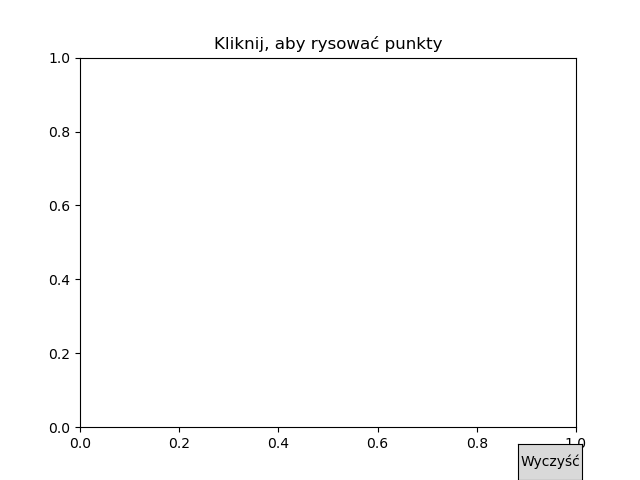

In [4]:
polygon = PolygonDrawer()

### Algorytm dolna i górna otoczka - wersja z wizualizacją algorytmu

In [5]:
def upper_and_lower_hull_visualisation(points):
    visualizer = ConvexHullVisualizer()
    
    if len(points) <= 2:
        return points
    
    sorted_points = sorted(points, key = lambda point: (point.x, point.y))
    
    upper_hull = [sorted_points[0], sorted_points[1]]
    lower_hull = [sorted_points[0], sorted_points[1]]
    
    for point in sorted_points:
        visualizer.add_frame(points, [], [upper_hull, lower_hull], [], None)
        
        while len(upper_hull) >= 2 and position(upper_hull[-2], upper_hull[-1], point) != -1:
            upper_hull.pop()
            visualizer.add_frame(points, [], [upper_hull, lower_hull], [], None)
        upper_hull.append(point)
        
        while len(lower_hull) >= 2 and position(lower_hull[-2], lower_hull[-1], point) != 1:
            lower_hull.pop()
            visualizer.add_frame(points, [], [upper_hull, lower_hull], [], None)
        lower_hull.append(point)
    
    visualizer.add_frame(points, [], [upper_hull, lower_hull], [], None)
    upper_hull.pop()
    lower_hull.reverse()
    lower_hull.pop()
    
    display(visualizer.create_animation())

Wizualizacja algorytmu dolna i górna otoczka

In [6]:
upper_and_lower_hull_visualisation(polygon.points)